In [74]:
import numpy as np
import roboticstoolbox as rtb
from spatialmath import *
from math import pi
import matplotlib.pyplot as plt
from matplotlib import cm
from roboticstoolbox import DHRobot, RevoluteDH, PrismaticDH
np.set_printoptions(linewidth=100, formatter={'float': lambda x: f"{x:8.4g}" if abs(x) > 1e-10 else f"{0:8.4g}"})

%matplotlib inline

In [75]:
robot = DHRobot(
    [
        RevoluteDH(),
        RevoluteDH(a=0.517),
        RevoluteDH(a=0.428)
    ], name="URC_Arm")

In [76]:
print(robot)

DHRobot: URC_Arm, 3 joints (RRR), dynamics, standard DH parameters
┌─────┬────┬───────┬──────┐
│ θⱼ  │ dⱼ │  aⱼ   │  ⍺ⱼ  │
├─────┼────┼───────┼──────┤
│  q1 │  0 │     0 │ 0.0° │
│  q2 │  0 │ 0.517 │ 0.0° │
│  q3 │  0 │ 0.428 │ 0.0° │
└─────┴────┴───────┴──────┘

┌──┬──┐
└──┴──┘



In [77]:
q = [np.pi/6, -np.pi/2, 0]  # theta1, theta2, theta3

In [62]:
T = robot.fkine(q)

In [63]:
print(T)

   0.5       0.866     0         0.4725    
  -0.866     0.5       0        -0.8184    
   0         0         1         0         
   0         0         0         1         



In [78]:
sol = robot.ikine_LM(T)

In [79]:
print(sol)

IKSolution: q=[0.05198, 0.3308, 1.796], success=True, iterations=7, searches=1, residual=6.86e-11


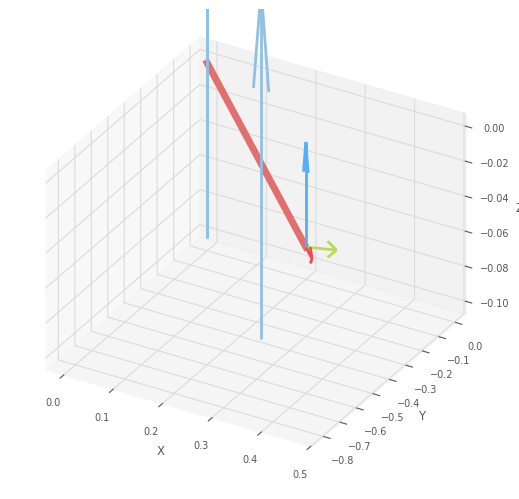

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'URC_Arm')

<Figure size 640x480 with 0 Axes>

In [80]:
robot.plot(q)

Theta1: 89.57796385647808 deg
Theta2: 67.49797719177718 deg
DHRobot: 2R_Arm, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬───────┬──────┐
│ θⱼ  │ dⱼ │  aⱼ   │  ⍺ⱼ  │
├─────┼────┼───────┼──────┤
│  q1 │  0 │ 0.517 │ 0.0° │
│  q2 │  0 │ 0.428 │ 0.0° │
└─────┴────┴───────┴──────┘

┌──┬──┐
└──┴──┘

End-effector pose:
    0.9267   -0.3759    0         0.4004    
   0.3759    0.9267    0         0.6779    
   0         0         1         0         
   0         0         0         1         



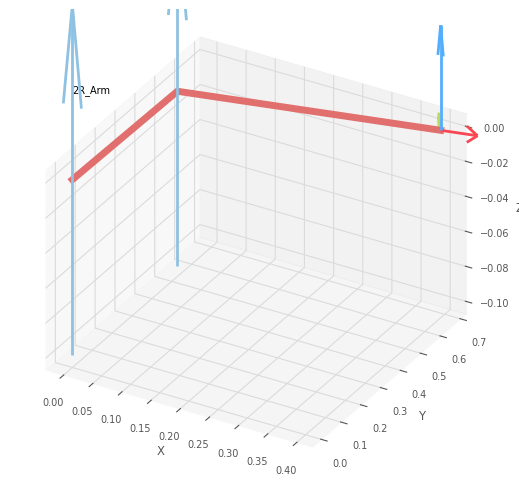

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, '2R_Arm')

<Figure size 640x480 with 0 Axes>

In [89]:
import numpy as np
from roboticstoolbox import DHRobot, RevoluteDH
import matplotlib.pyplot as plt

# Robot link lengths
L1, L2 = 0.517, 0.428
# Actuator mount distances
S1, r1 = 0.164, 0.250
S2, r2 = 0.180, 0.180

# Function to compute joint angles from actuator extensions
def actuators_to_angles(d1, d2):
    # Shoulder angle
    theta1 = np.arccos((d1**2 - r1**2 - S1**2)/(2*r1*S1))
    # Elbow angle
    theta2 = np.arccos((r2**2 + S2**2 - d2**2)/(2*r2*S2))
    return theta1, theta2

# Example actuator positions (meters)
d1, d2 = 0.3, 0.2

theta1, theta2 = actuators_to_angles(d1, d2)
print("Theta1:", np.degrees(theta1), "deg")
print("Theta2:", np.degrees(theta2), "deg")

# Define robot using DH parameters
robot = DHRobot([
    RevoluteDH(a=L1),
    RevoluteDH(a=L2)
], name="2R_Arm")

print(robot)

# Forward kinematics
T = robot.fkine([theta1, -theta2])
print("End-effector pose:\n", T)

# Plot robot
robot.plot([theta1, -theta2])


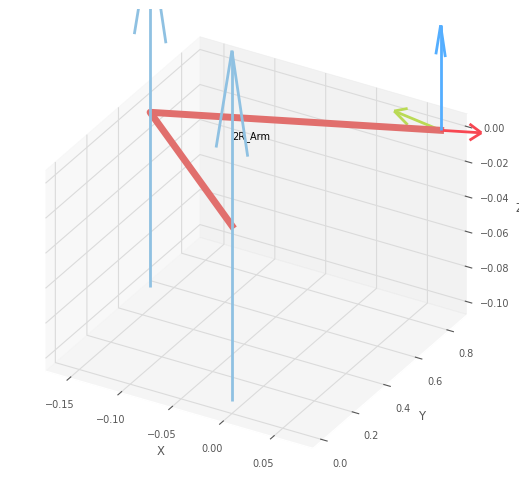

<Figure size 640x480 with 0 Axes>

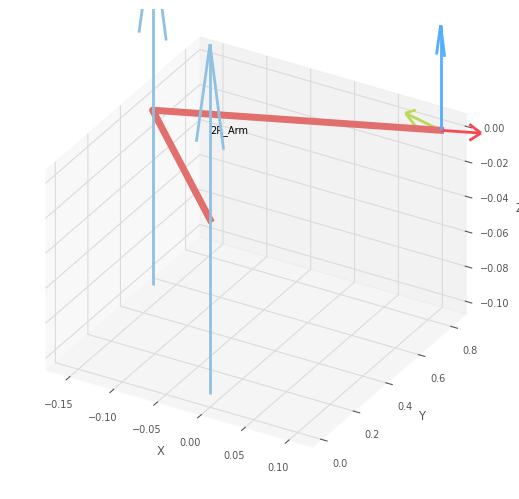

<Figure size 640x480 with 0 Axes>

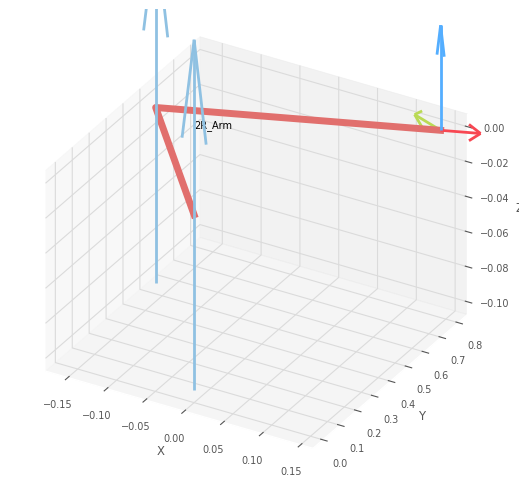

<Figure size 640x480 with 0 Axes>

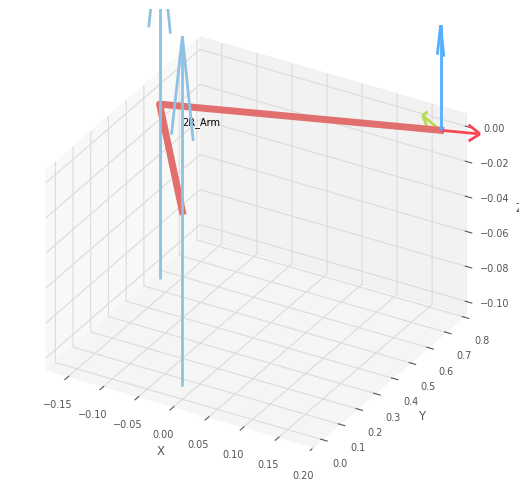

<Figure size 640x480 with 0 Axes>

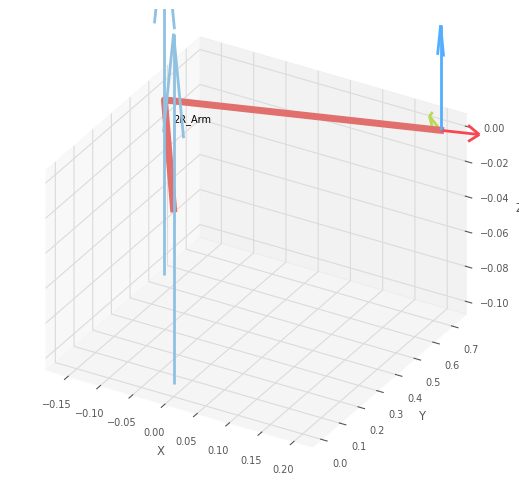

<Figure size 640x480 with 0 Axes>

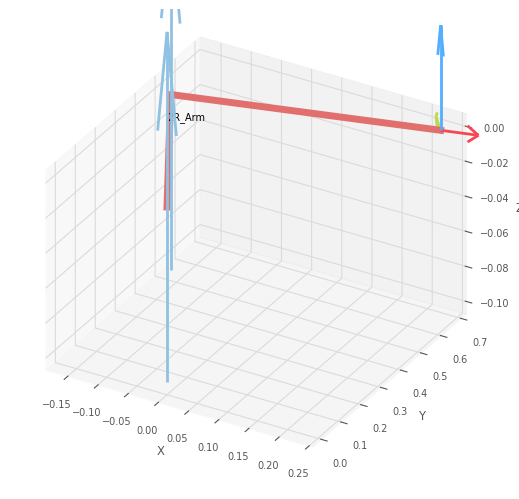

<Figure size 640x480 with 0 Axes>

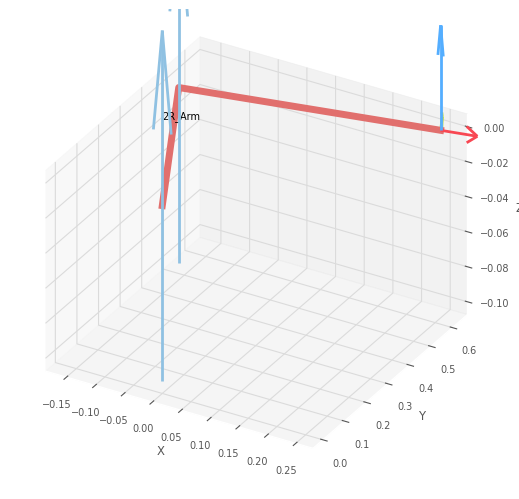

<Figure size 640x480 with 0 Axes>

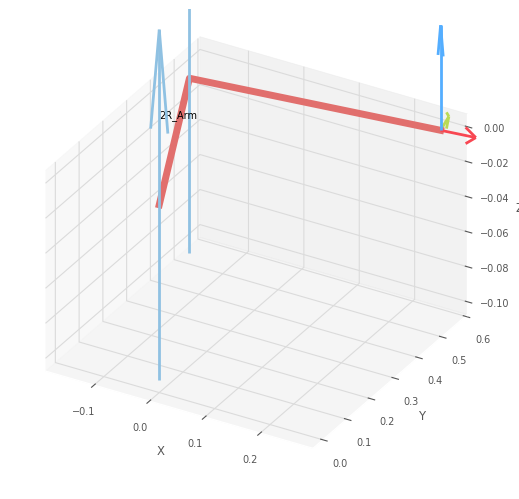

<Figure size 640x480 with 0 Axes>

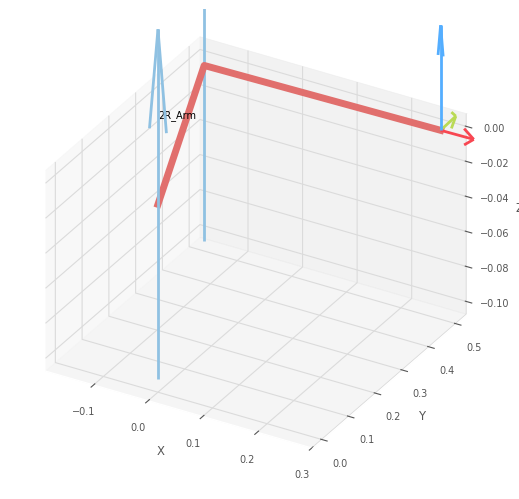

<Figure size 640x480 with 0 Axes>

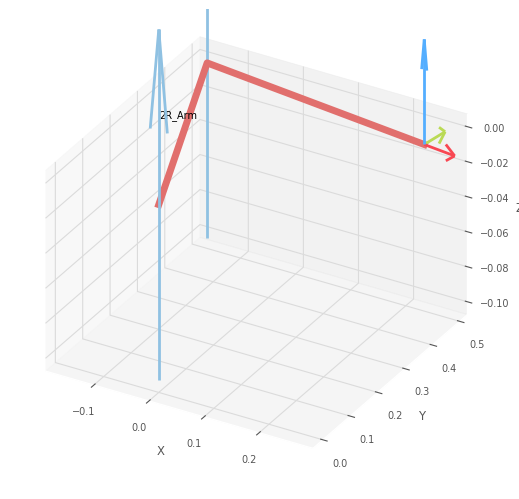

<Figure size 640x480 with 0 Axes>

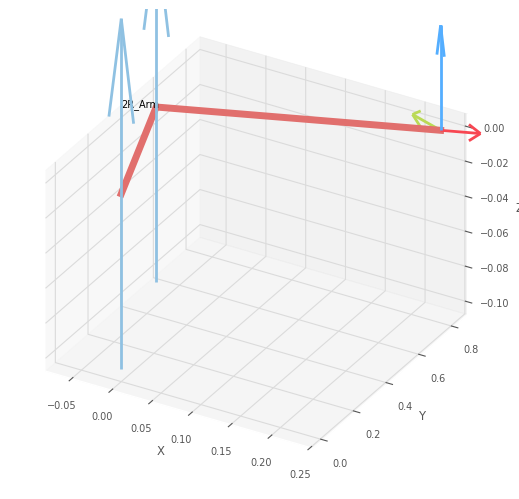

<Figure size 640x480 with 0 Axes>

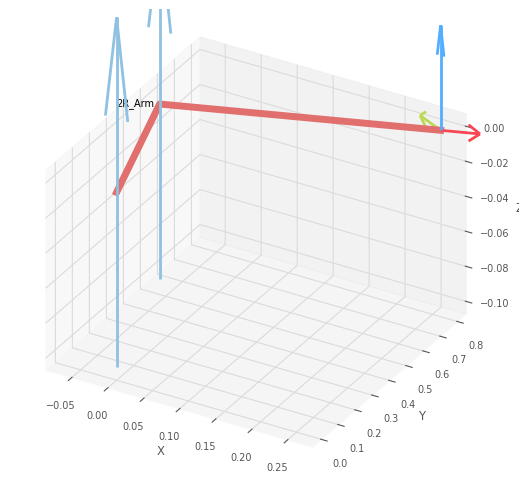

<Figure size 640x480 with 0 Axes>

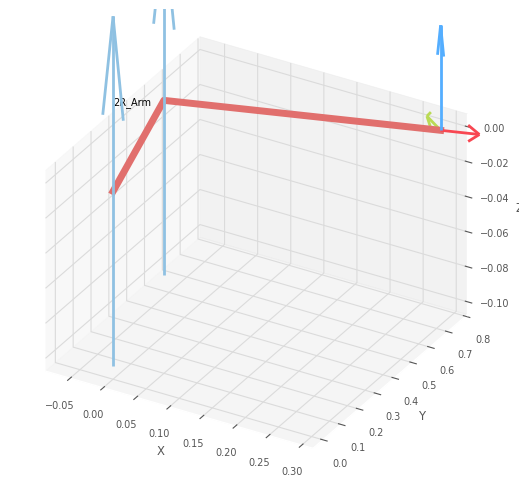

<Figure size 640x480 with 0 Axes>

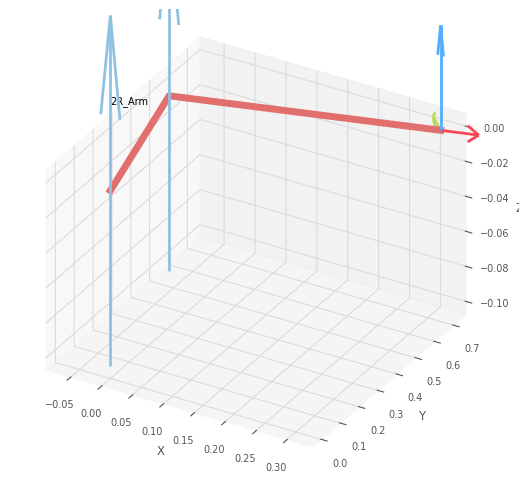

<Figure size 640x480 with 0 Axes>

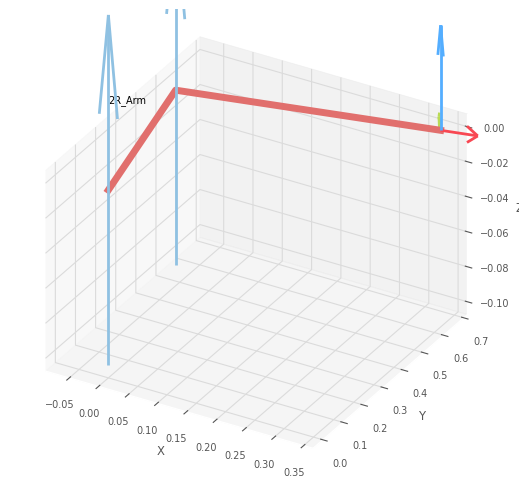

<Figure size 640x480 with 0 Axes>

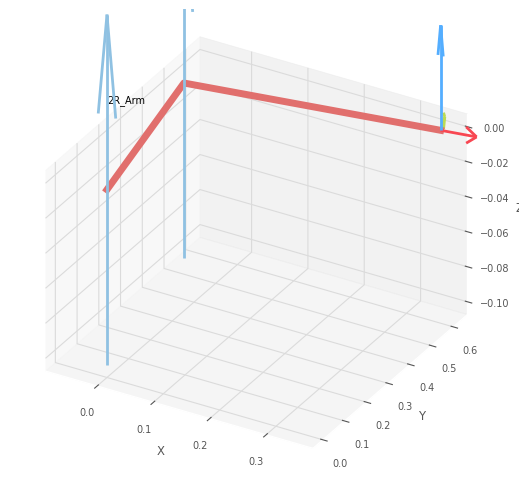

<Figure size 640x480 with 0 Axes>

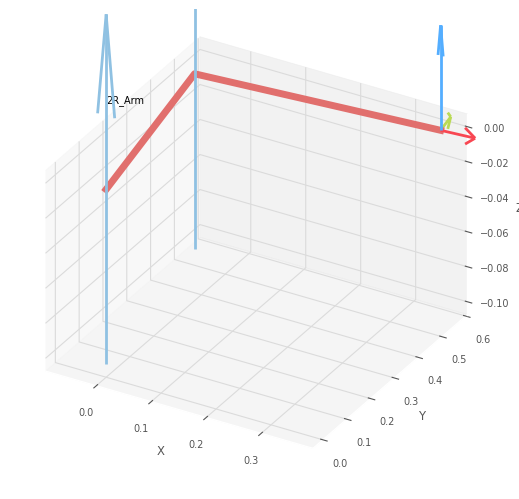

<Figure size 640x480 with 0 Axes>

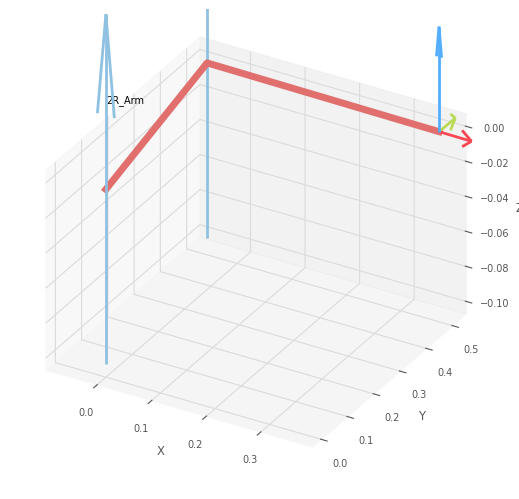

<Figure size 640x480 with 0 Axes>

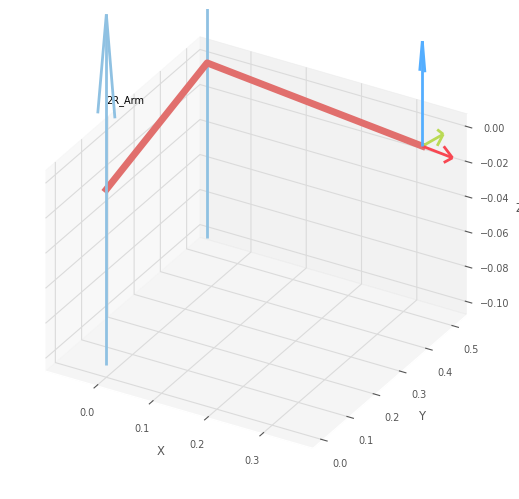

<Figure size 640x480 with 0 Axes>

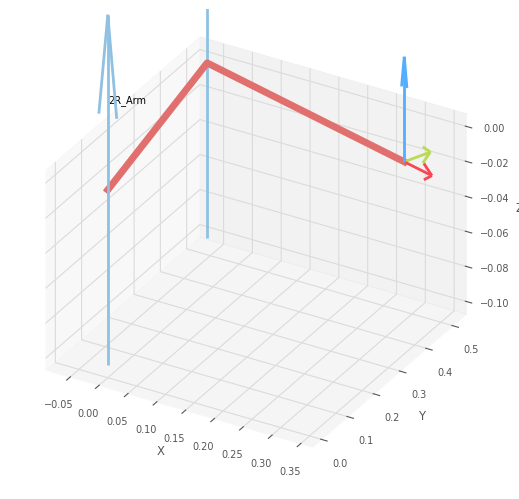

<Figure size 640x480 with 0 Axes>

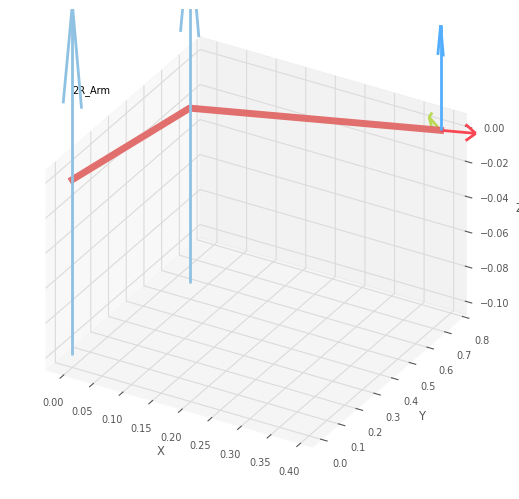

<Figure size 640x480 with 0 Axes>

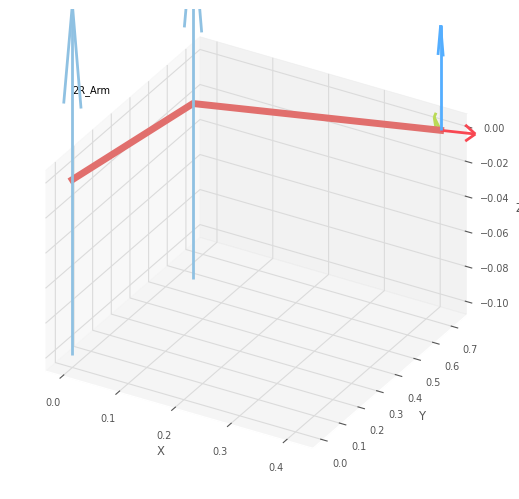

<Figure size 640x480 with 0 Axes>

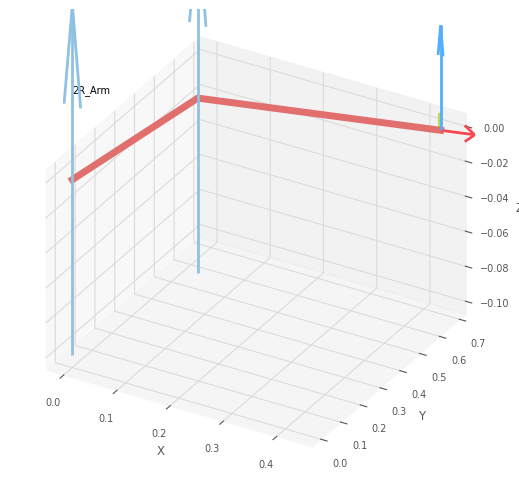

<Figure size 640x480 with 0 Axes>

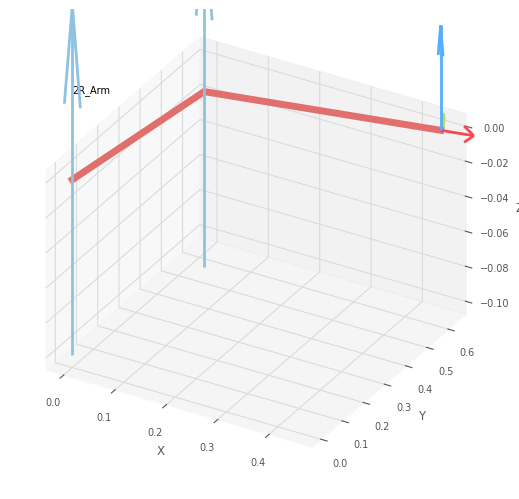

<Figure size 640x480 with 0 Axes>

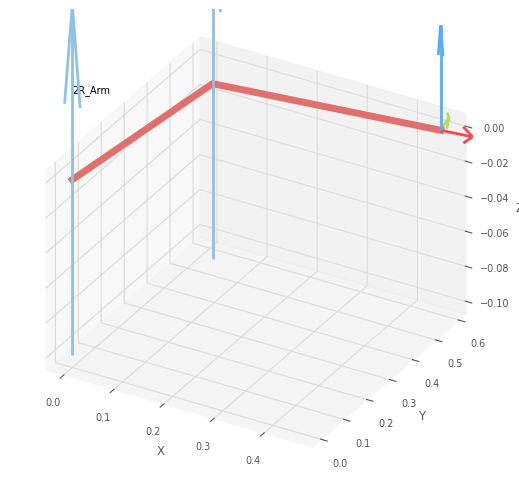

<Figure size 640x480 with 0 Axes>

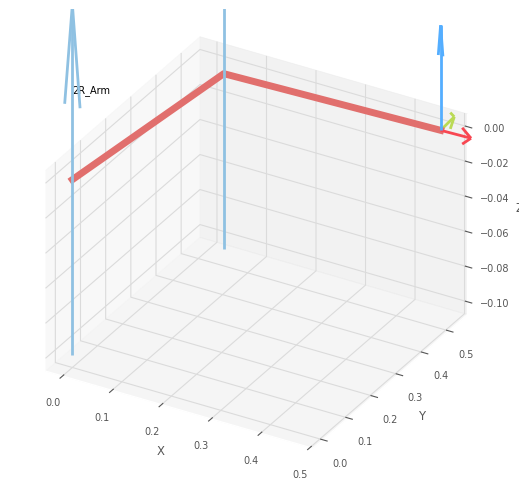

<Figure size 640x480 with 0 Axes>

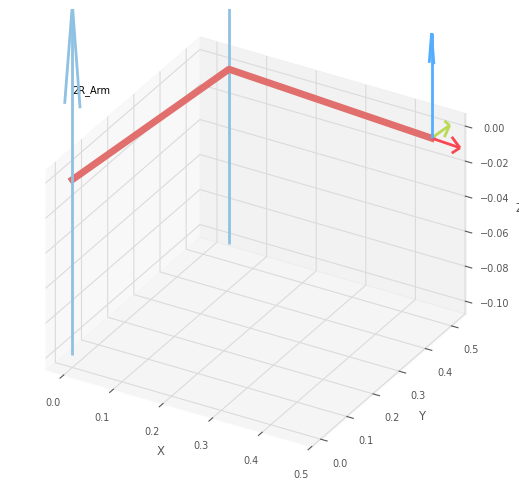

<Figure size 640x480 with 0 Axes>

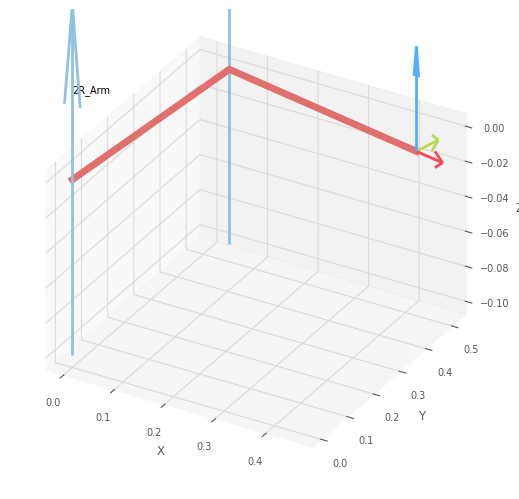

<Figure size 640x480 with 0 Axes>

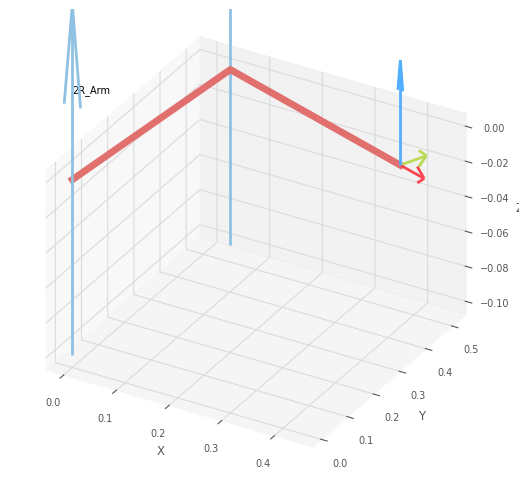

<Figure size 640x480 with 0 Axes>

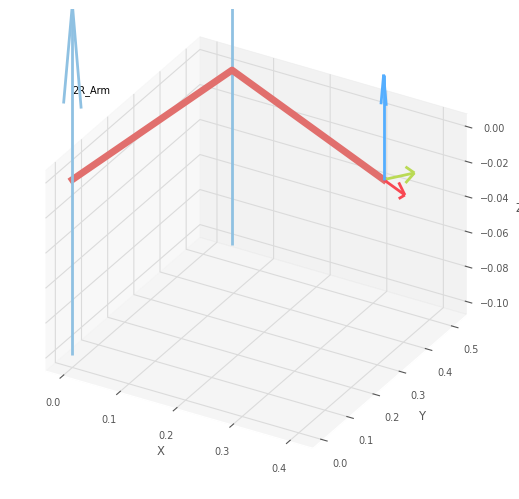

<Figure size 640x480 with 0 Axes>

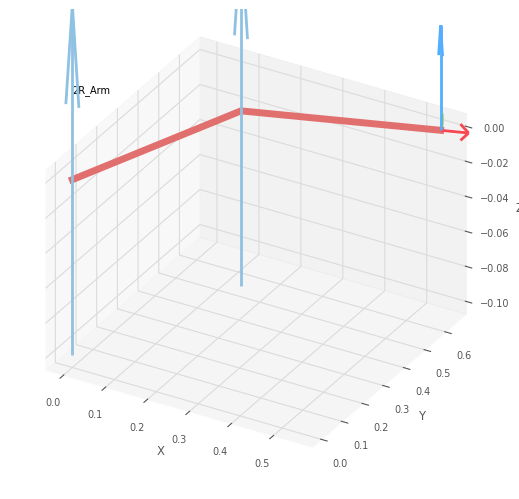

<Figure size 640x480 with 0 Axes>

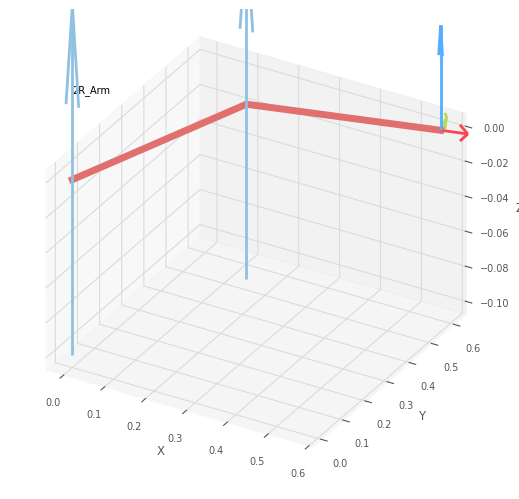

<Figure size 640x480 with 0 Axes>

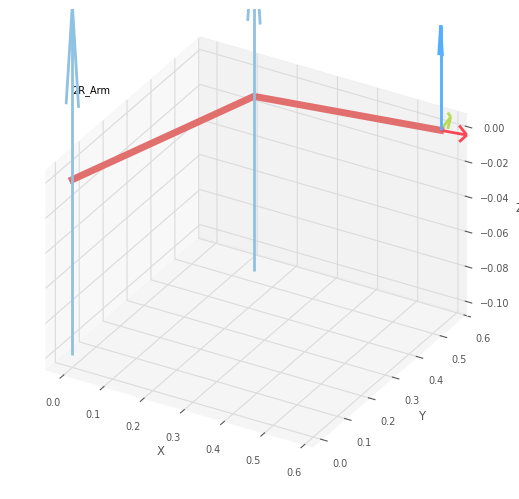

<Figure size 640x480 with 0 Axes>

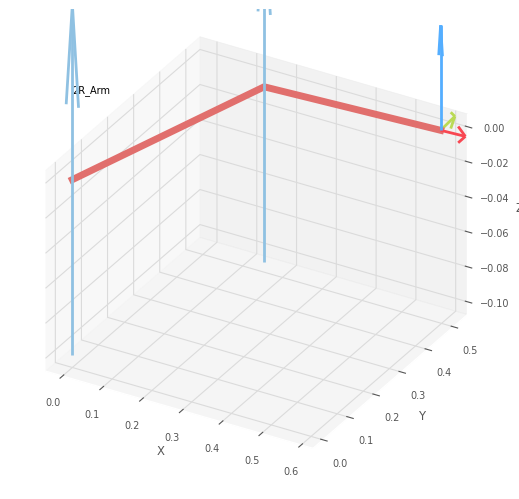

<Figure size 640x480 with 0 Axes>

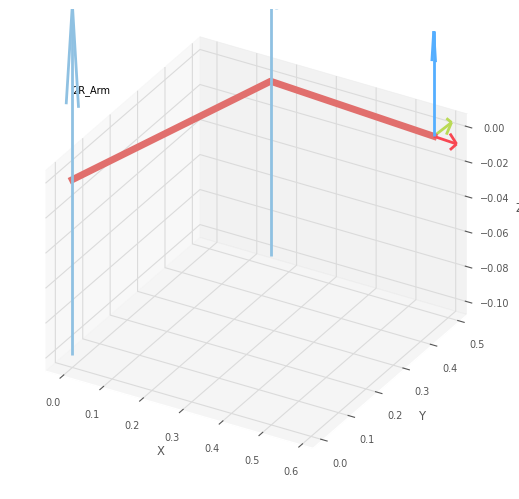

<Figure size 640x480 with 0 Axes>

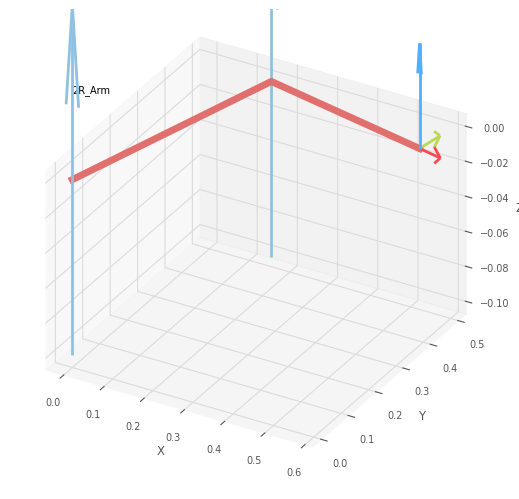

<Figure size 640x480 with 0 Axes>

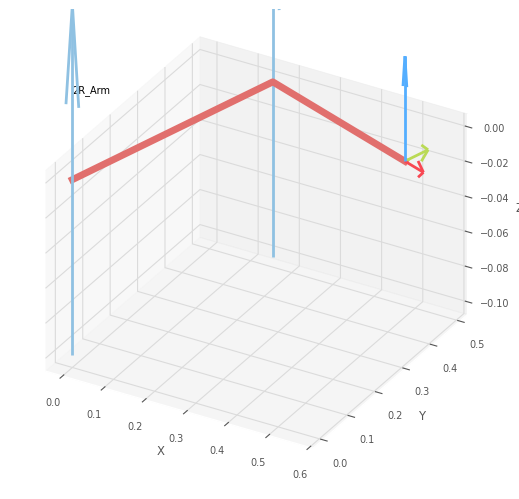

<Figure size 640x480 with 0 Axes>

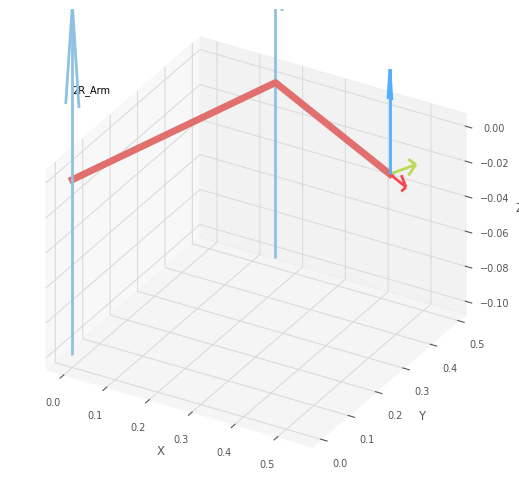

<Figure size 640x480 with 0 Axes>

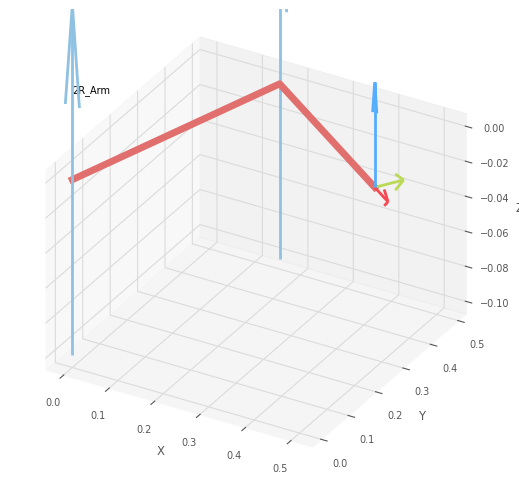

<Figure size 640x480 with 0 Axes>

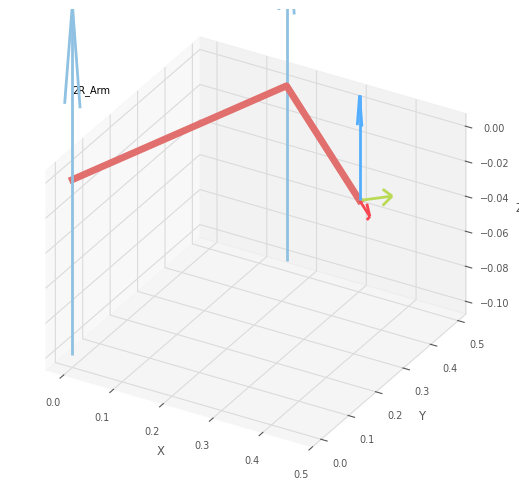

<Figure size 640x480 with 0 Axes>

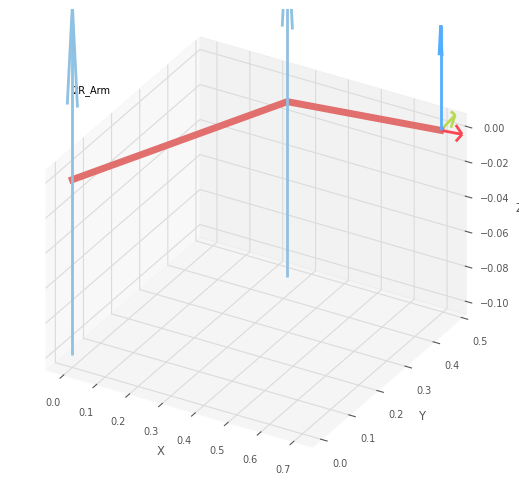

<Figure size 640x480 with 0 Axes>

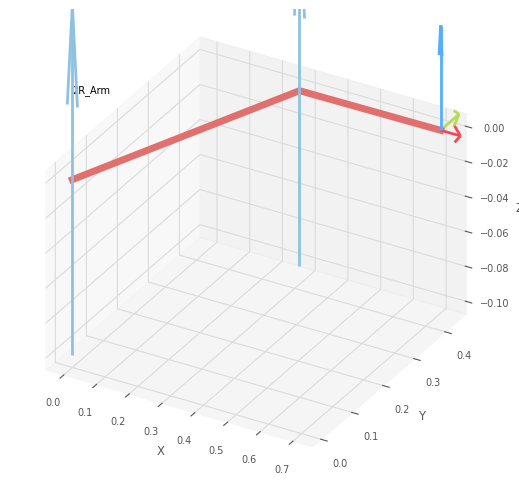

<Figure size 640x480 with 0 Axes>

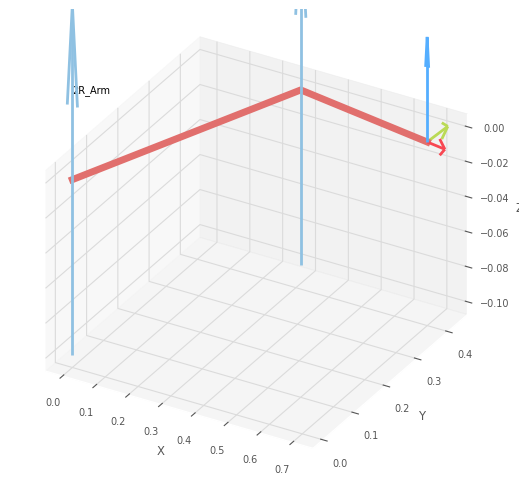

<Figure size 640x480 with 0 Axes>

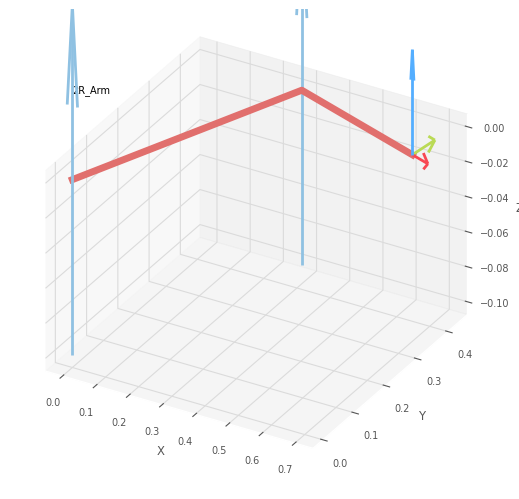

<Figure size 640x480 with 0 Axes>

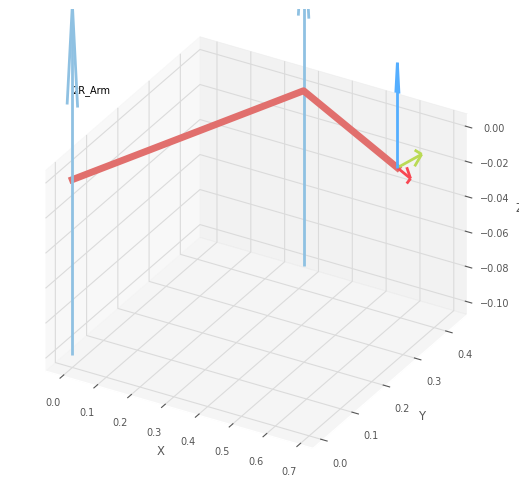

<Figure size 640x480 with 0 Axes>

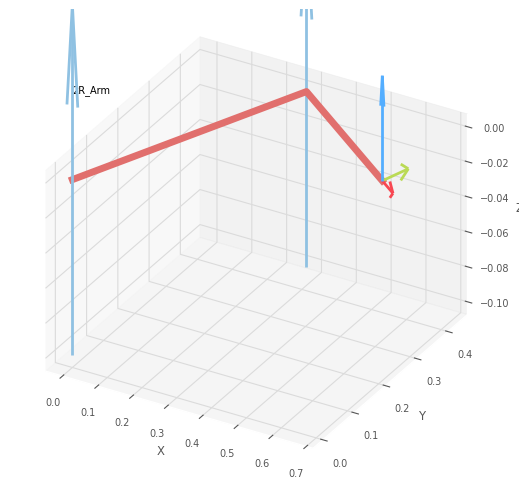

<Figure size 640x480 with 0 Axes>

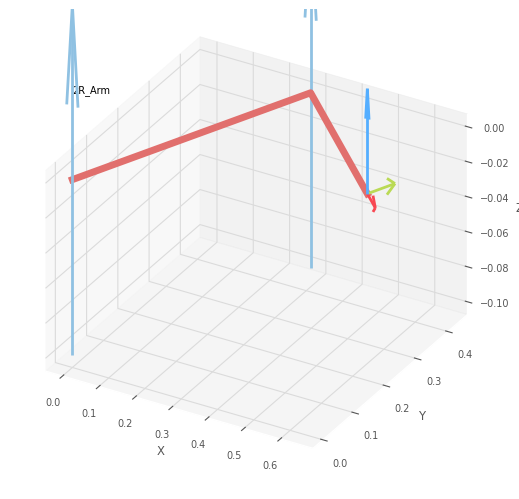

<Figure size 640x480 with 0 Axes>

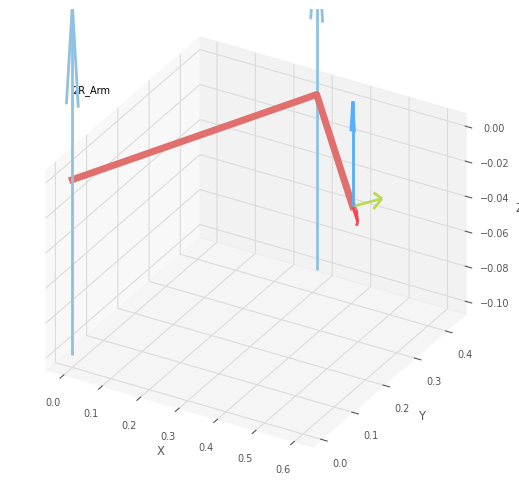

<Figure size 640x480 with 0 Axes>

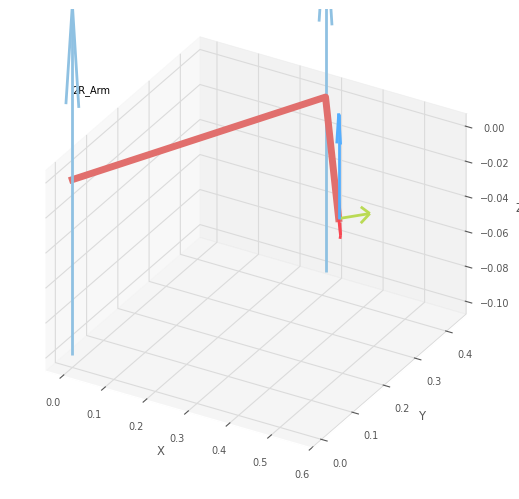

<Figure size 640x480 with 0 Axes>

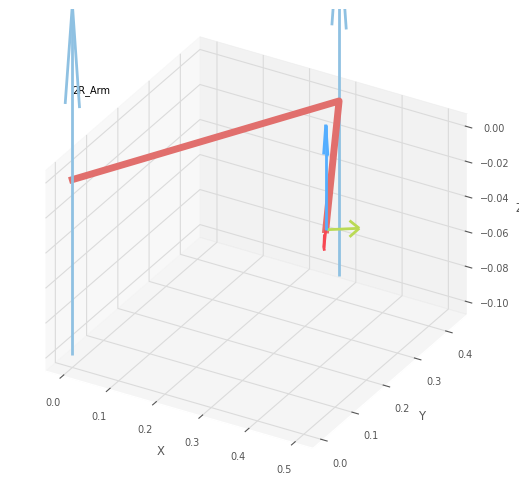

<Figure size 640x480 with 0 Axes>

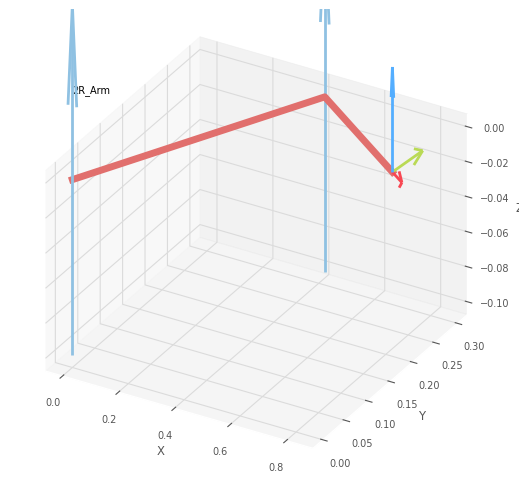

<Figure size 640x480 with 0 Axes>

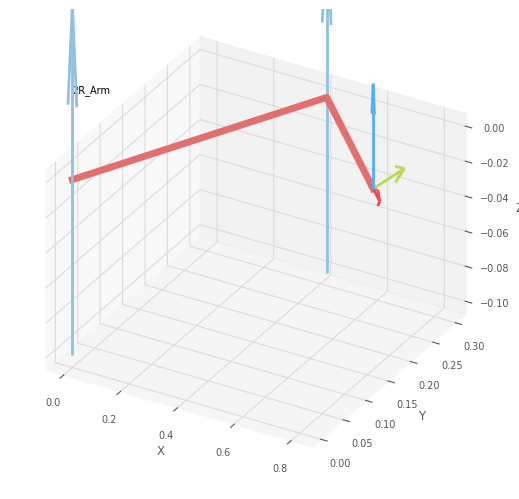

<Figure size 640x480 with 0 Axes>

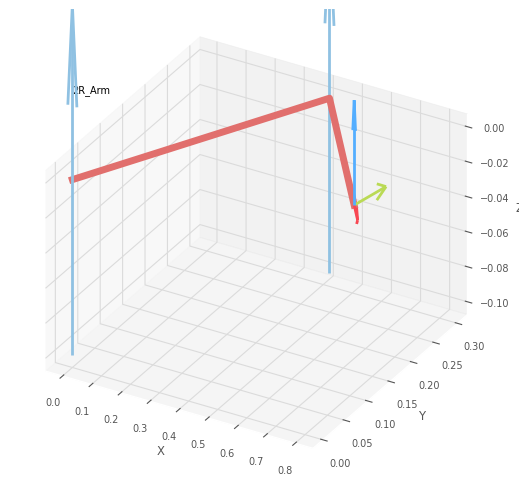

<Figure size 640x480 with 0 Axes>

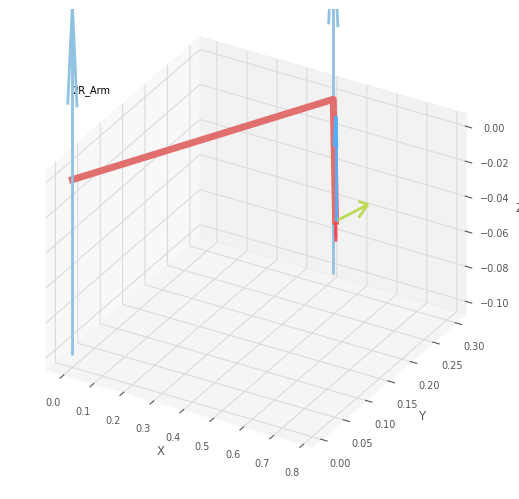

<Figure size 640x480 with 0 Axes>

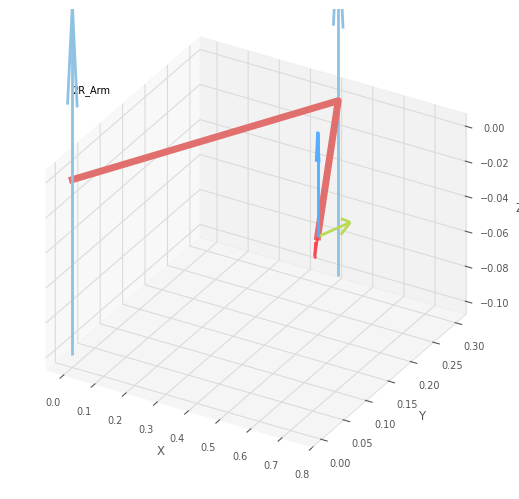

<Figure size 640x480 with 0 Axes>

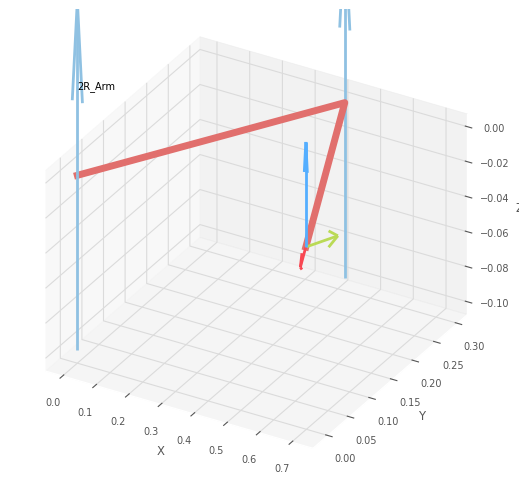

<Figure size 640x480 with 0 Axes>

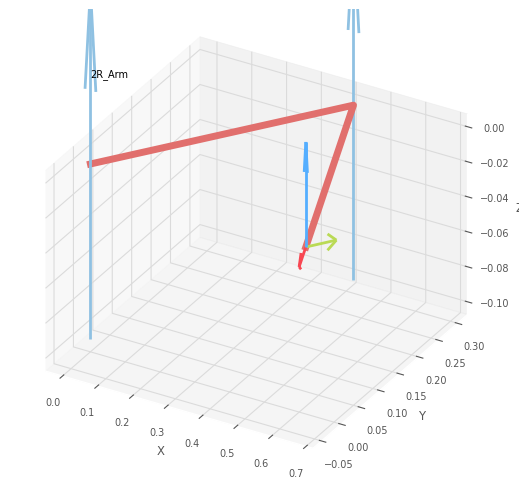

<Figure size 640x480 with 0 Axes>

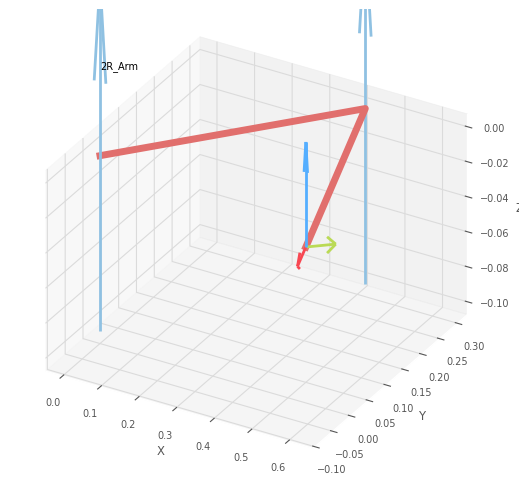

<Figure size 640x480 with 0 Axes>

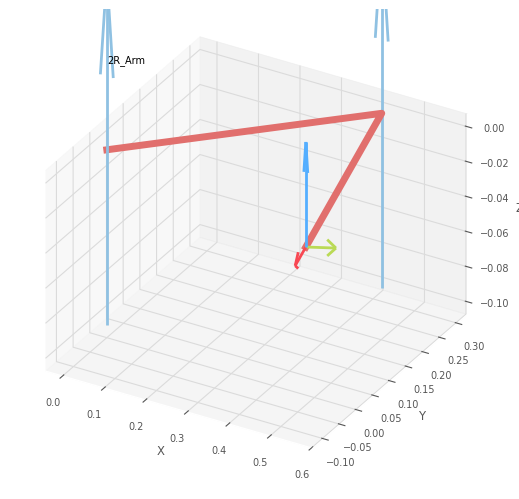

<Figure size 640x480 with 0 Axes>

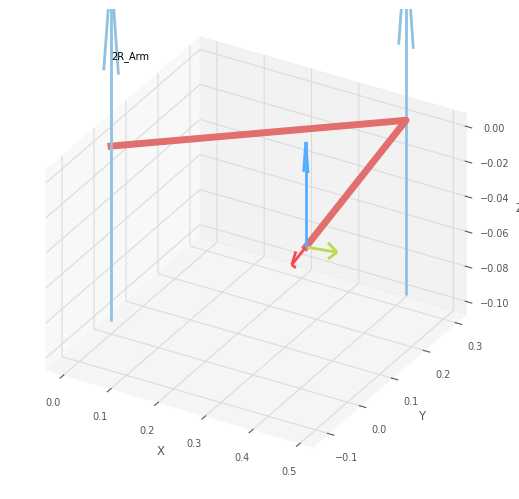

/var/folders/vd/6czmb8k14lnfk3f7xqg4_hrw0000gn/T/ipykernel_49440/2591204335.py:14: RuntimeWarning: invalid value encountered in arccos
  theta1 = np.arccos((d1**2 - r1**2 - S1**2)/(2*r1*S1))


<Figure size 640x480 with 0 Axes>

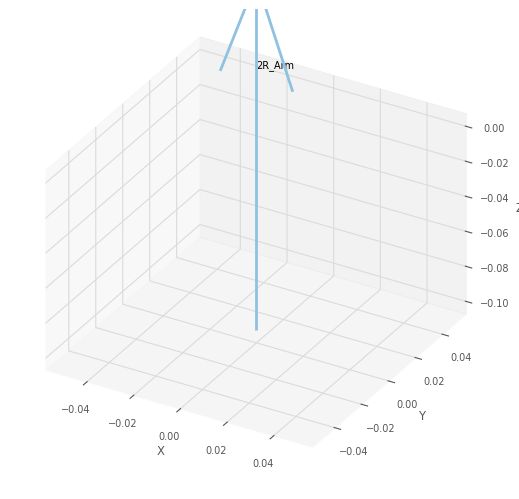

<Figure size 640x480 with 0 Axes>

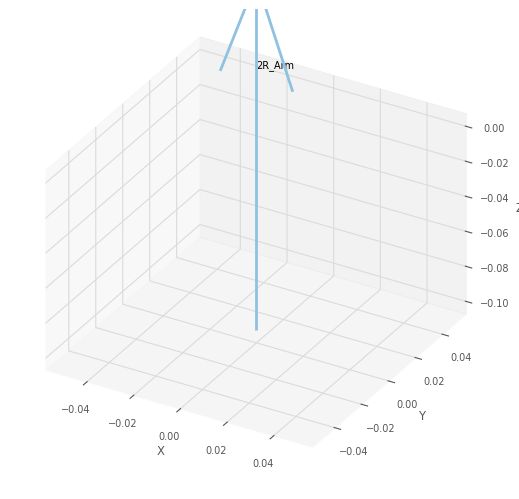

<Figure size 640x480 with 0 Axes>

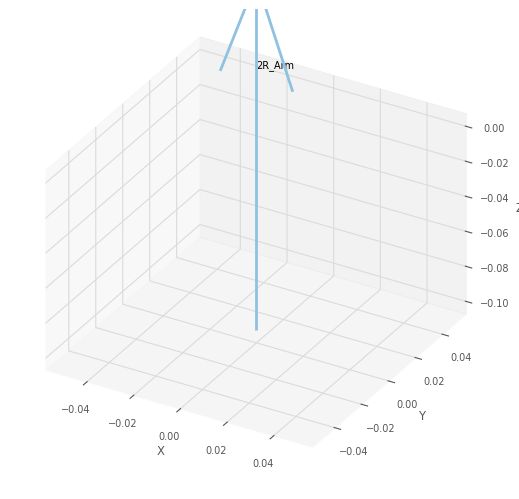

<Figure size 640x480 with 0 Axes>

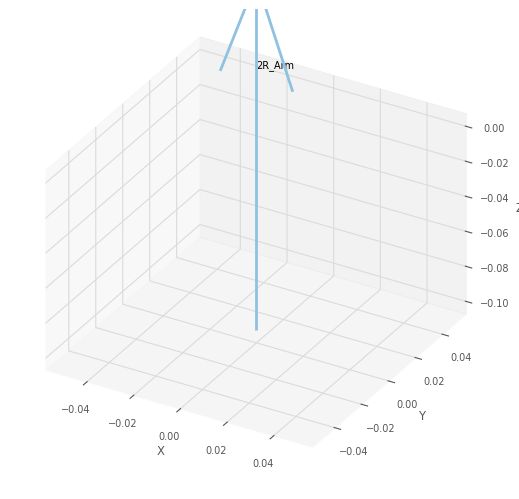

<Figure size 640x480 with 0 Axes>

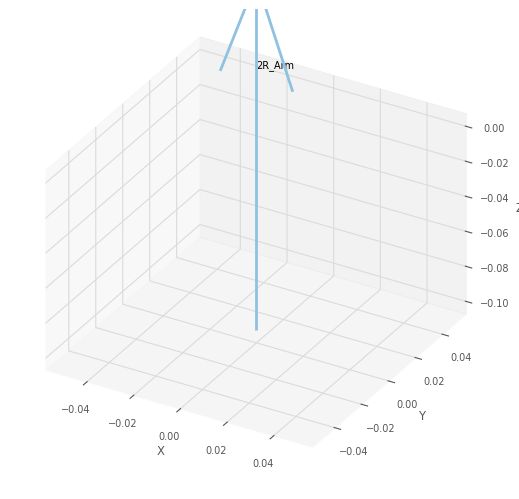

<Figure size 640x480 with 0 Axes>

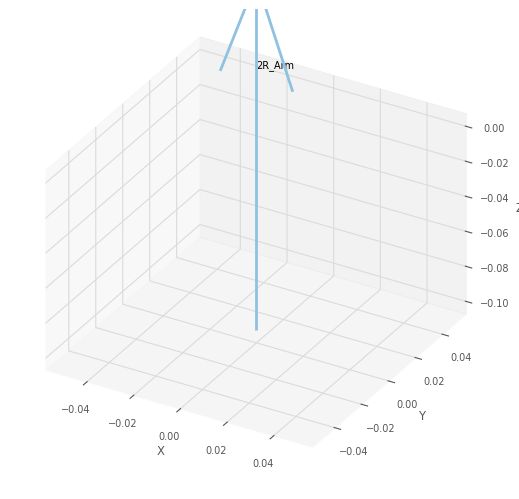

<Figure size 640x480 with 0 Axes>

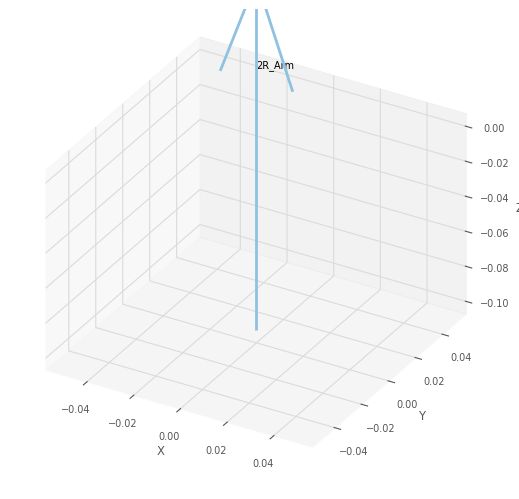

<Figure size 640x480 with 0 Axes>

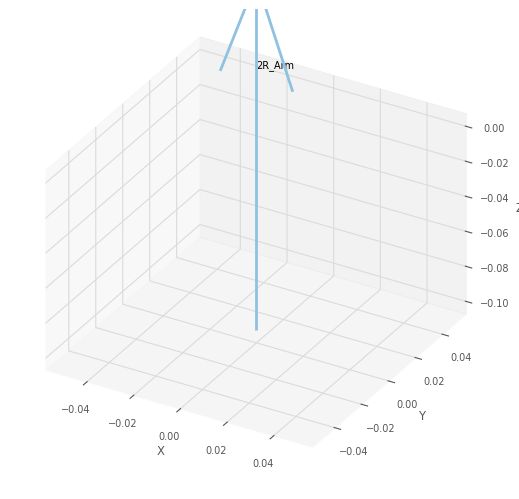

<Figure size 640x480 with 0 Axes>

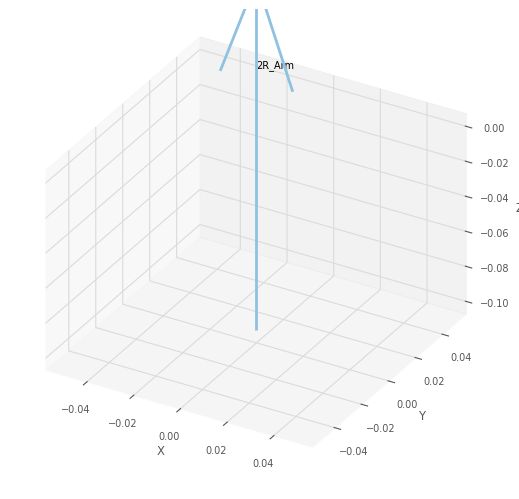

<Figure size 640x480 with 0 Axes>

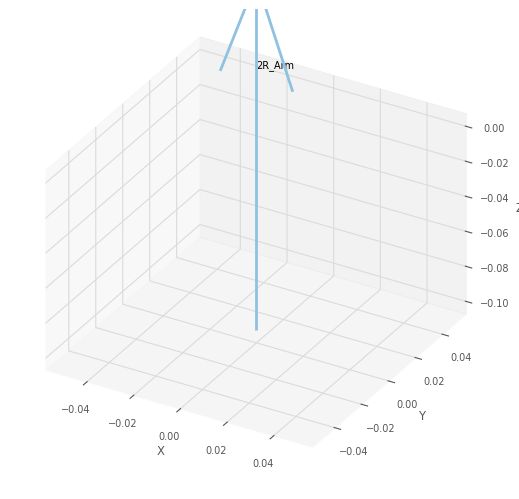

<Figure size 640x480 with 0 Axes>

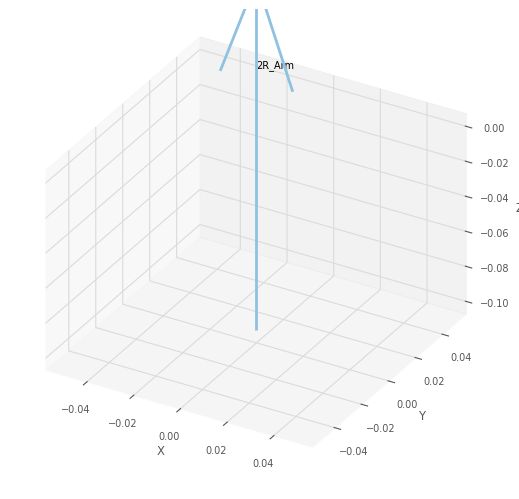

<Figure size 640x480 with 0 Axes>

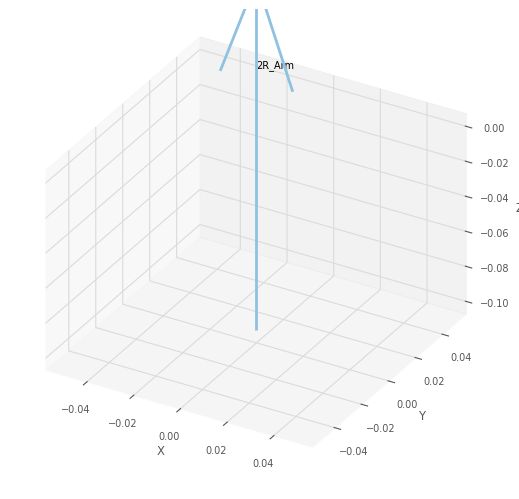

<Figure size 640x480 with 0 Axes>

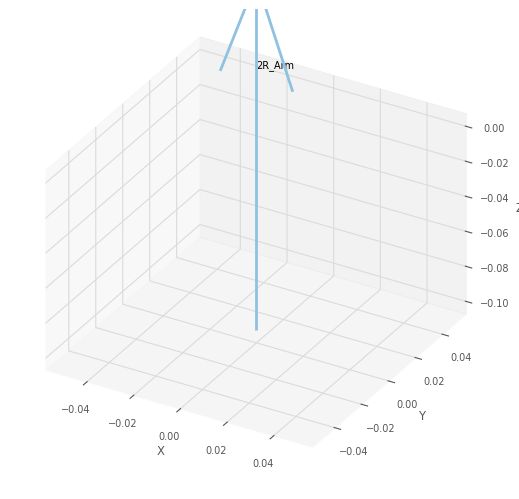

<Figure size 640x480 with 0 Axes>

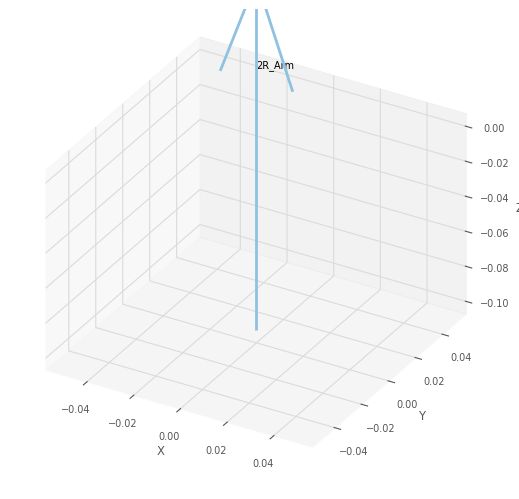

<Figure size 640x480 with 0 Axes>

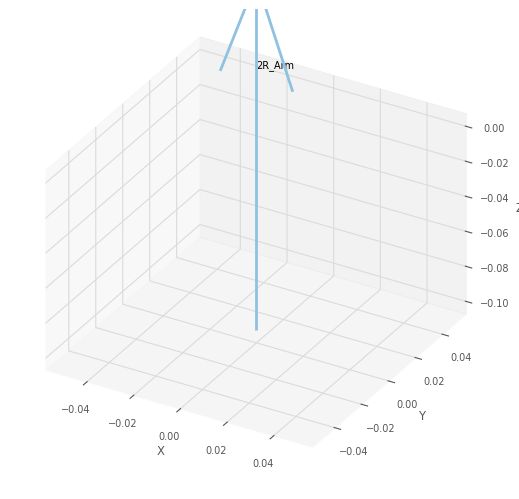

<Figure size 640x480 with 0 Axes>

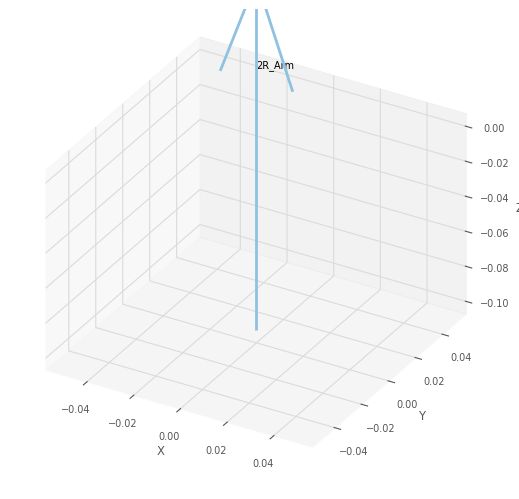

<Figure size 640x480 with 0 Axes>

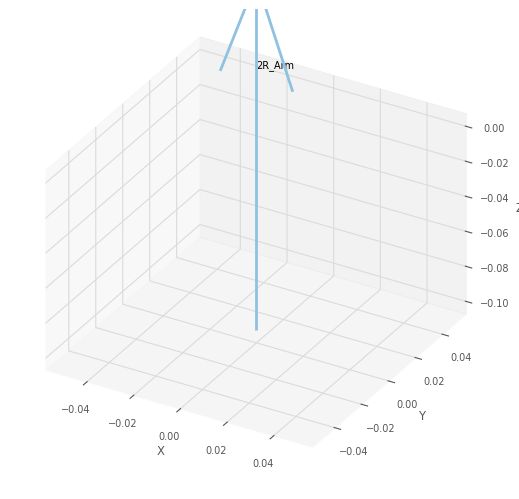

<Figure size 640x480 with 0 Axes>

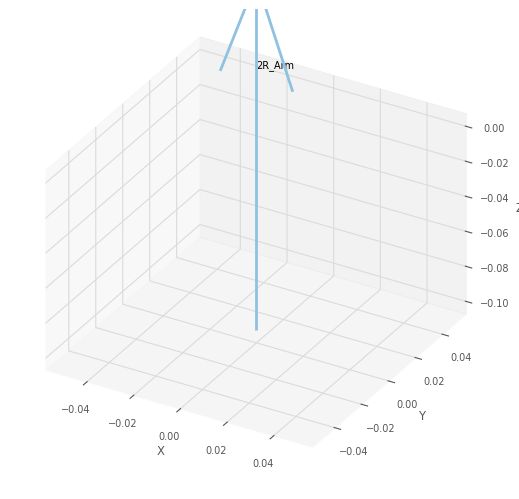

<Figure size 640x480 with 0 Axes>

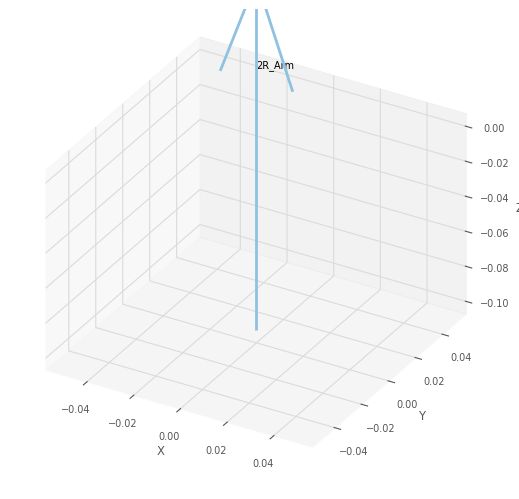

<Figure size 640x480 with 0 Axes>

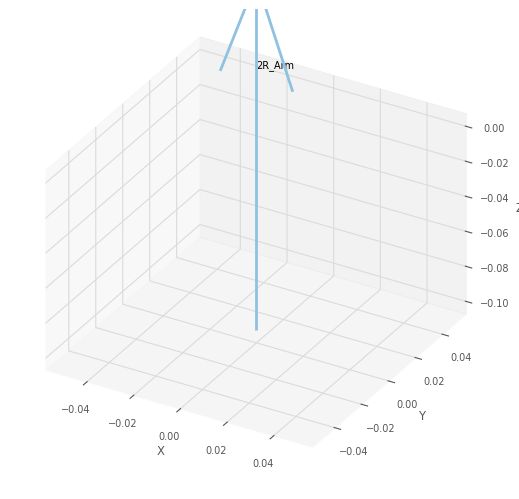

<Figure size 640x480 with 0 Axes>

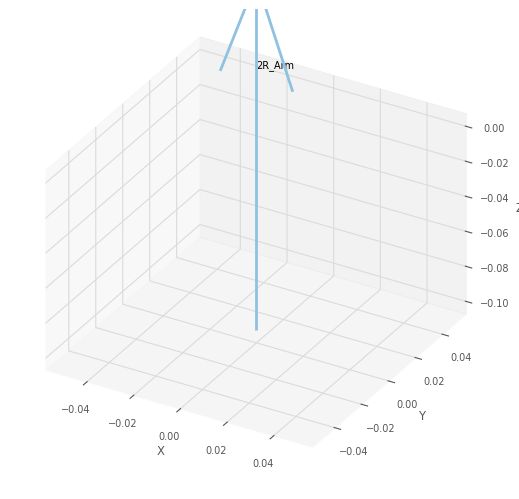

<Figure size 640x480 with 0 Axes>

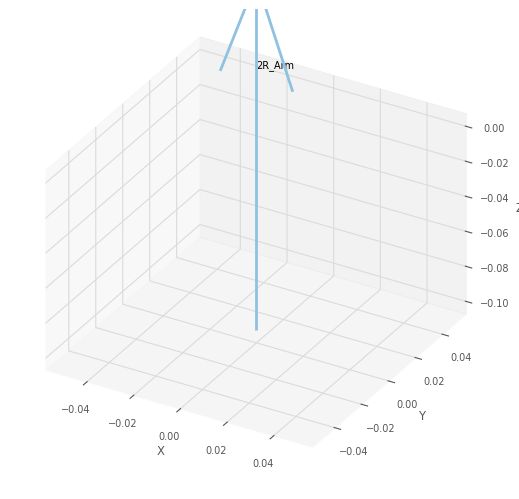

<Figure size 640x480 with 0 Axes>

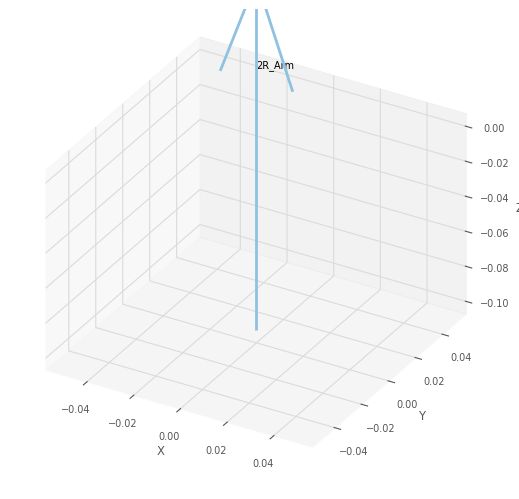

<Figure size 640x480 with 0 Axes>

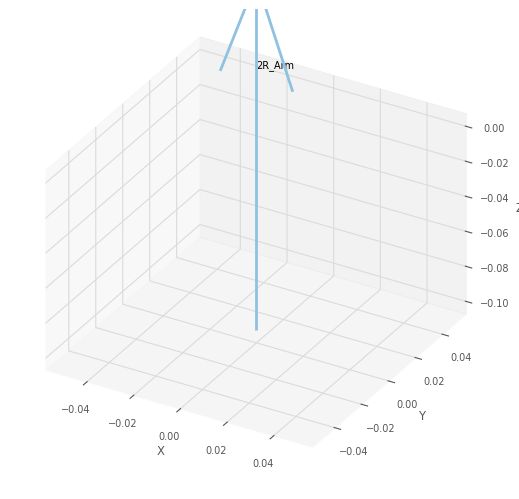

<Figure size 640x480 with 0 Axes>

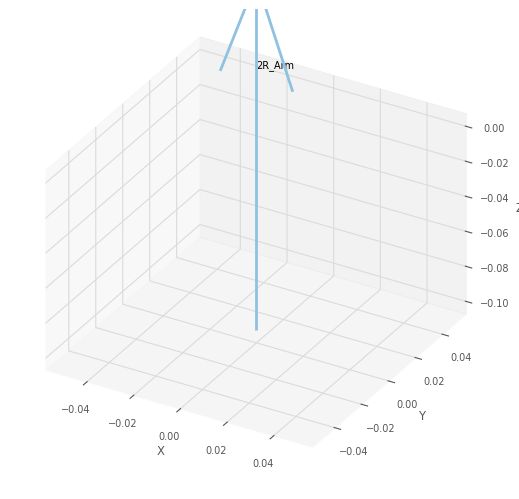

<Figure size 640x480 with 0 Axes>

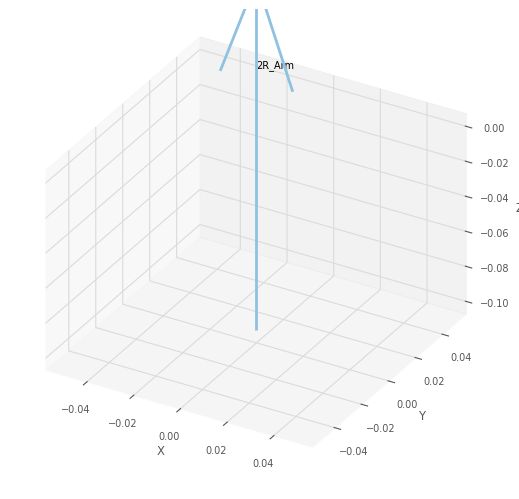

<Figure size 640x480 with 0 Axes>

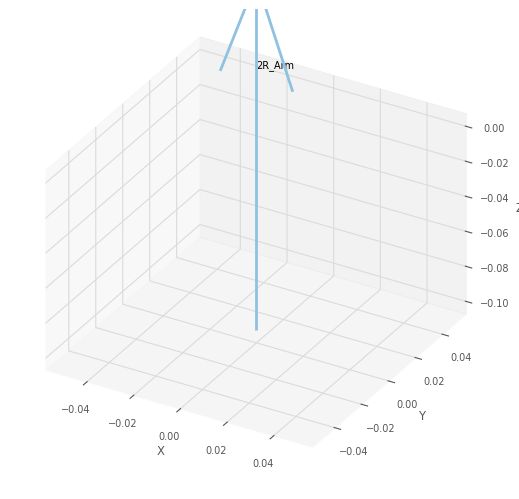

<Figure size 640x480 with 0 Axes>

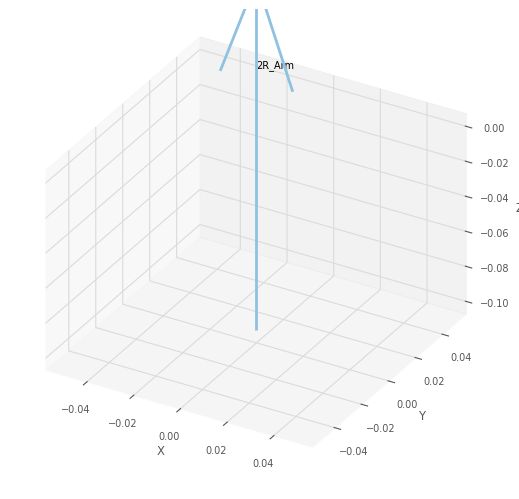

<Figure size 640x480 with 0 Axes>

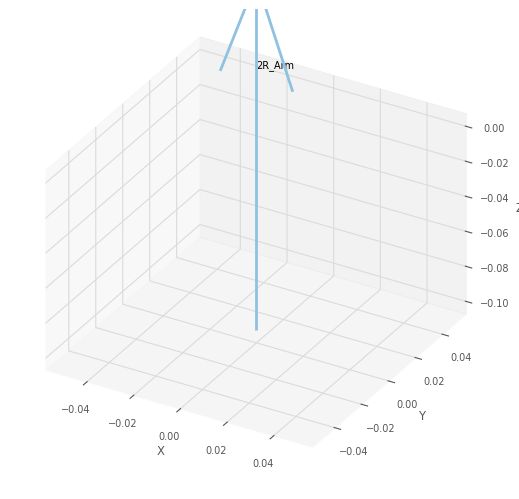

<Figure size 640x480 with 0 Axes>

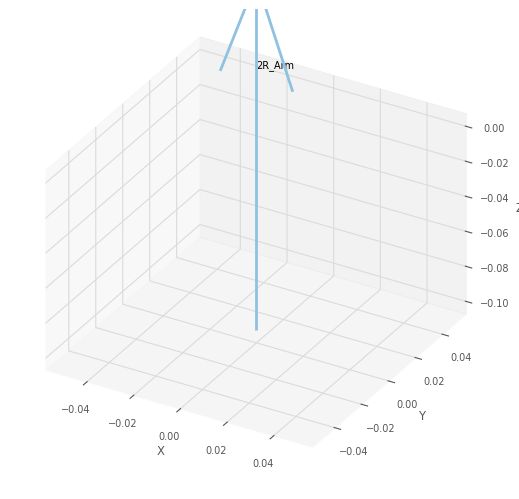

<Figure size 640x480 with 0 Axes>

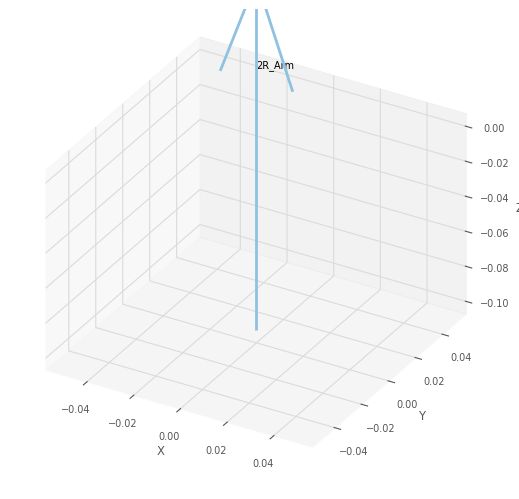

<Figure size 640x480 with 0 Axes>

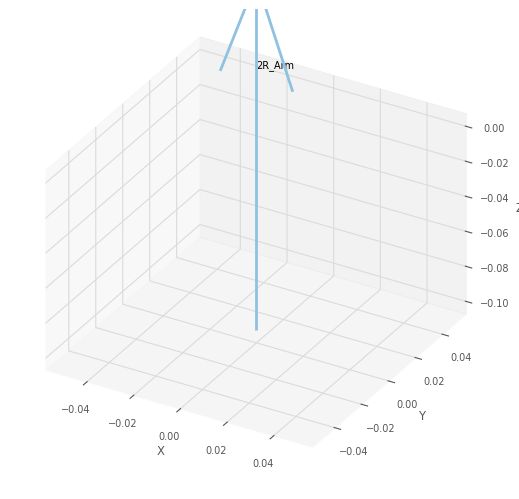

<Figure size 640x480 with 0 Axes>

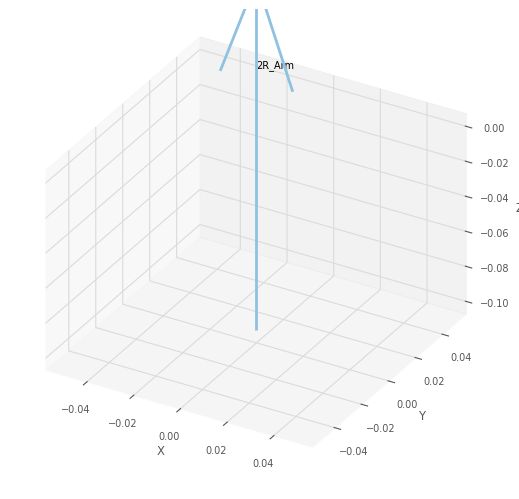

<Figure size 640x480 with 0 Axes>

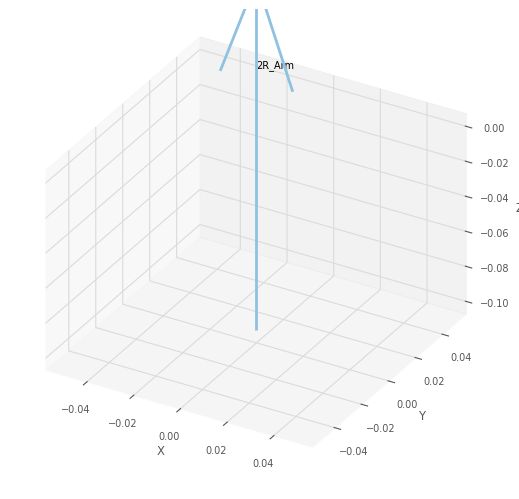

<Figure size 640x480 with 0 Axes>

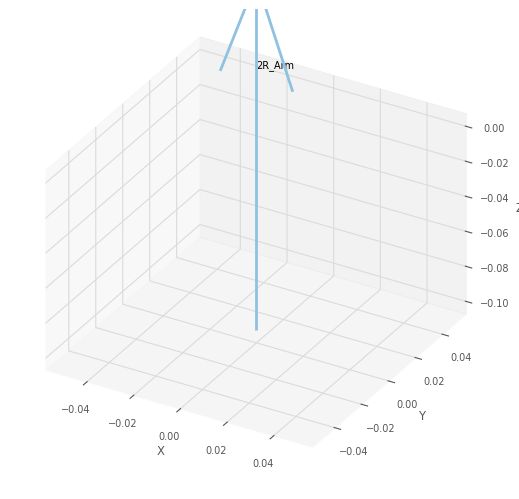

<Figure size 640x480 with 0 Axes>

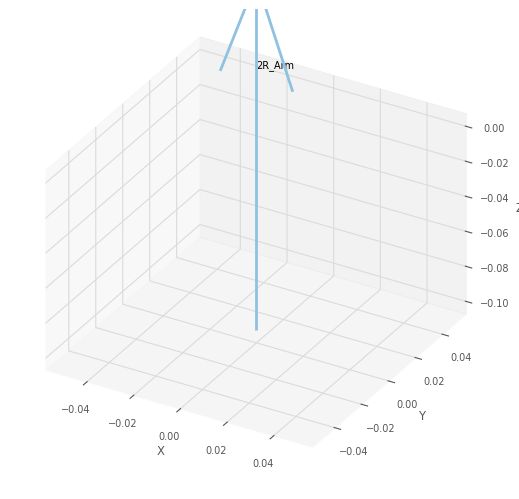

<Figure size 640x480 with 0 Axes>

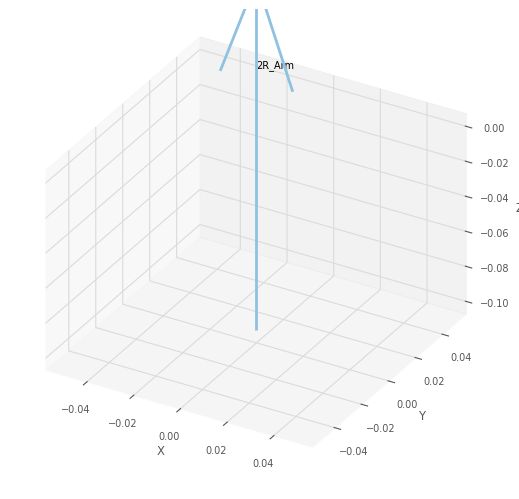

<Figure size 640x480 with 0 Axes>

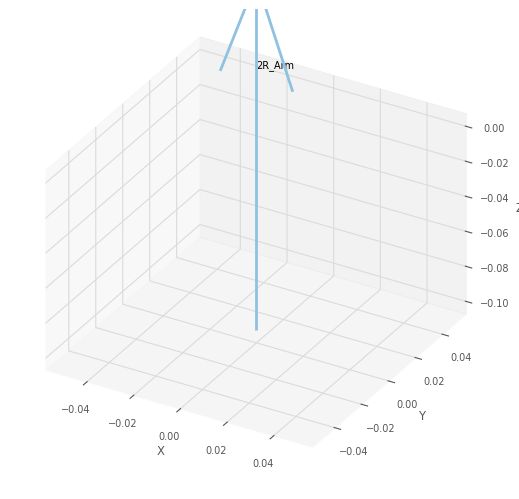

<Figure size 640x480 with 0 Axes>

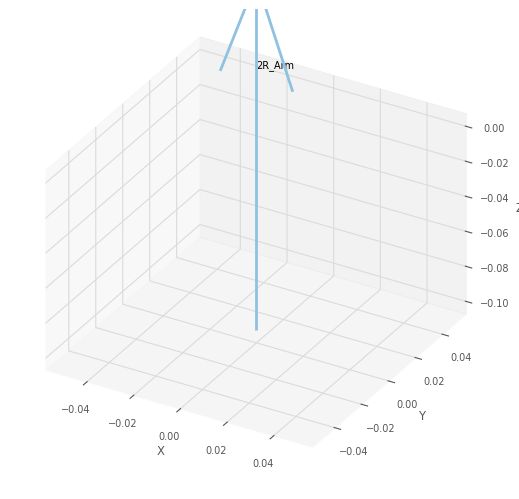

<Figure size 640x480 with 0 Axes>

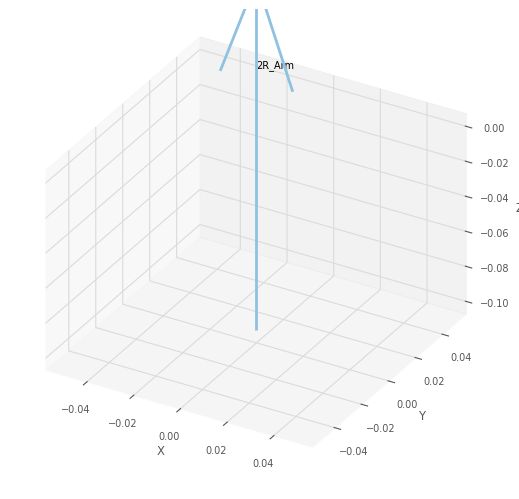

<Figure size 640x480 with 0 Axes>

In [92]:
d1_vals = np.linspace(0.254, 0.508, 10)  # example range
d2_vals = np.linspace(0.1524, 0.3048, 10)

for d1 in d1_vals:
    for d2 in d2_vals:
        theta1, theta2 = actuators_to_angles(d1, d2)
        robot.plot([theta1, -theta2])

Theta1: 89.57796385647808 deg
Theta2: 67.49797719177718 deg
DHRobot: 2R_Arm, 3 joints (RRR), dynamics, standard DH parameters
┌─────┬────┬───────┬──────┐
│ θⱼ  │ dⱼ │  aⱼ   │  ⍺ⱼ  │
├─────┼────┼───────┼──────┤
│  q1 │  0 │     0 │ 0.0° │
│  q2 │  0 │ 0.517 │ 0.0° │
│  q3 │  0 │ 0.428 │ 0.0° │
└─────┴────┴───────┴──────┘

┌──┬──┐
└──┴──┘

End-effector pose:
    0.9267   -0.3759    0         0.8757    
   0.3759    0.9267    0         0.3552    
   0         0         1         0         
   0         0         0         1         



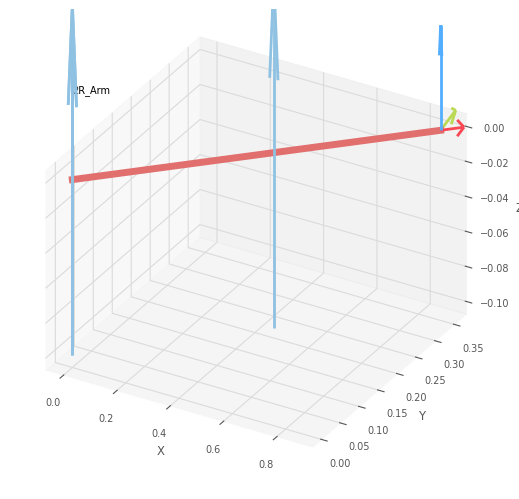

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, '2R_Arm')

<Figure size 640x480 with 0 Axes>

In [93]:
import numpy as np
from roboticstoolbox import DHRobot, RevoluteDH
import matplotlib.pyplot as plt

# Robot link lengths
L1, L2 = 0.517, 0.428
# Actuator mount distances
S1, r1 = 0.164, 0.250
S2, r2 = 0.180, 0.180

# Function to compute joint angles from actuator extensions
def actuators_to_angles(d1, d2):
    # Shoulder angle
    theta1 = np.arccos((d1**2 - r1**2 - S1**2)/(2*r1*S1))
    # Elbow angle
    theta2 = np.arccos((r2**2 + S2**2 - d2**2)/(2*r2*S2))
    return theta1, theta2

# Example actuator positions (meters)
d1, d2 = 0.3, 0.2

theta1, theta2 = actuators_to_angles(d1, d2)
print("Theta1:", np.degrees(theta1), "deg")
print("Theta2:", np.degrees(theta2), "deg")

# Define robot using DH parameters
robot = DHRobot([
    RevoluteDH(),
    RevoluteDH(a=L1),
    RevoluteDH(a=L2)
], name="2R_Arm")

print(robot)

# Forward kinematics
T = robot.fkine([theta1, -theta2, 0])
print("End-effector pose:\n", T)

# Plot robot
robot.plot([theta1, -theta2, 0])
